# 2.2 Balanced joint sparse analysis of substrate-feature alignment

This notebook asks a focused question:

> After ligand variation is included in the fitted model, do the substrate
> features associated with Ru-AHO selectivity show greater compatibility with
> mechanism-aligned than with mechanism-mismatched Ru-AHK?

The primary model jointly fits:

- 40 unsupervisedly selected substrate MACCS bits;
- 40 unsupervisedly selected ligand MACCS bits.

Only the **substrate coefficient block** is used for cross-domain
interpretation. Ligand features are included to account for ligand variation
within the sparse predictive model.

The analysis uses 100 balanced repeats. In each repeat, 90% of the smallest
domain is sampled without replacement from all three domains, producing 88
observations per domain for the current data. One common feature scaler and one
common ddG scaler are fitted on the pooled sampled rows and reused across the
three domain-specific L1 models.

The main outputs follow the manuscript order:

1. the fraction of balanced repeats favoring the mechanism-aligned domain for
   feature-effect direction and important-feature overlap;
2. selection frequency and median standardized coefficient for the
   representative substrate feature MACCS 132;
3. representative substrate structures containing MACCS 132.

The figures are displayed in the notebook and saved under:

`results/2_2_substrate_feature_alignment/`

The coefficients describe predictive associations with selectivity magnitude.
They are not interpreted as causal effects or as absolute stereochemical
preference directions.


In [1]:
from __future__ import annotations

from collections import OrderedDict
from pathlib import Path
import hashlib
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
from IPython.display import SVG, display

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Draw, MACCSkeys
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.linear_model import Lasso


RDLogger.DisableLog("rdApp.*")

SEED = 42
PRIMARY_REPEATS = 100
LASSO_ALPHA = 0.02
COEFFICIENT_THRESHOLD = 0.10
STABILITY_FREQUENCY_THRESHOLD = 0.60
SIGN_STABILITY_THRESHOLD = 0.80
ACTIVE_REPEAT_MINIMUM = 80
FEATURE_CAP = 40

DOMAIN_ORDER = ["target", "inner", "outer"]
DOMAIN_LABELS = {
    "target": "Ru-AHO",
    "inner": "Mechanism-aligned Ru-AHK",
    "outer": "Mechanism-mismatched Ru-AHK",
}
DOMAIN_COLORS = {
    "target": "#222222",
    "inner": "#0072B2",
    "outer": "#D55E00",
}

CONDITION_COLUMNS = ["Pressure/atm", "Temperature/C", "S/C"]

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "none",
    }
)


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "transfer").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TRANSFER_DIR = PROJECT_ROOT / "data" / "transfer"
OUT_DIR = PROJECT_ROOT / "results" / "2_2_substrate_feature_alignment"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
STRUCTURE_DIR = OUT_DIR / "structures"
for directory in [FIG_DIR, TABLE_DIR, STRUCTURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DATA_PATHS = {
    "target": TRANSFER_DIR / "ru_aho_inner.csv",
    "inner": TRANSFER_DIR / "ru_ahk_inner.csv",
    "outer": TRANSFER_DIR / "ru_ahk_outer.csv",
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUT_DIR.relative_to(PROJECT_ROOT)}")

Project root: /home/syz/ru-mechanism-transfer
Output directory: results/2_2_substrate_feature_alignment


## 1. Load and audit the three mechanism domains

Substrate and ligand structures are canonicalized deterministically. Rows with
invalid ddG, substrate, or ligand values are excluded before the balanced
analysis.

In [2]:
def canonicalize(value):
    raw = "" if pd.isna(value) else str(value).strip()
    if not raw:
        return None
    molecule = Chem.MolFromSmiles(raw)
    if molecule is None:
        return None
    for atom in molecule.GetAtoms():
        atom.SetAtomMapNum(0)
    return Chem.MolToSmiles(
        molecule,
        canonical=True,
        isomericSmiles=True,
    )


def maccs_array(smiles):
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        raise ValueError(f"Invalid canonical SMILES: {smiles}")
    vector = np.zeros(167, dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(
        MACCSkeys.GenMACCSKeys(molecule),
        vector,
    )
    return vector


def scaffold_smiles(smiles):
    molecule = Chem.MolFromSmiles(smiles)
    scaffold = MurckoScaffold.GetScaffoldForMol(molecule)
    if scaffold is None or scaffold.GetNumAtoms() == 0:
        return smiles
    return Chem.MolToSmiles(scaffold, canonical=True)


DOMAINS = OrderedDict()
MATRICES = {}
audit_rows = []

for domain in DOMAIN_ORDER:
    path = DATA_PATHS[domain]
    if not path.exists():
        raise FileNotFoundError(path)

    table = pd.read_csv(path).reset_index(drop=True)
    required = ["ddG", "Reactant SMILES", "Ligand SMILES"]
    missing = [column for column in required if column not in table.columns]
    if missing:
        raise KeyError(f"{domain} is missing columns: {missing}")

    table["row_id"] = [
        f"{domain}_{index:04d}"
        for index in range(len(table))
    ]
    table["ddG"] = pd.to_numeric(table["ddG"], errors="coerce")
    table["canonical_substrate"] = table["Reactant SMILES"].map(
        canonicalize
    )
    table["canonical_ligand"] = table["Ligand SMILES"].map(
        canonicalize
    )

    valid = (
        table["ddG"].notna()
        & table["canonical_substrate"].notna()
        & table["canonical_ligand"].notna()
    )
    clean = table.loc[valid].reset_index(drop=True)
    clean["substrate_scaffold"] = clean[
        "canonical_substrate"
    ].map(scaffold_smiles)

    MATRICES[(domain, "substrate")] = np.vstack(
        clean["canonical_substrate"].map(maccs_array)
    )
    MATRICES[(domain, "ligand")] = np.vstack(
        clean["canonical_ligand"].map(maccs_array)
    )
    DOMAINS[domain] = clean

    audit_rows.append(
        {
            "domain": domain,
            "input_file": str(path.relative_to(PROJECT_ROOT)),
            "raw_rows": len(table),
            "analysis_rows": len(clean),
            "excluded_rows": int((~valid).sum()),
            "unique_substrates": clean[
                "canonical_substrate"
            ].nunique(),
            "unique_ligands": clean[
                "canonical_ligand"
            ].nunique(),
            "ddG_min": clean["ddG"].min(),
            "ddG_max": clean["ddG"].max(),
            "contains_negative_ddG": bool(
                (clean["ddG"] < 0).any()
            ),
        }
    )

INPUT_AUDIT = pd.DataFrame(audit_rows)
INPUT_AUDIT.to_csv(TABLE_DIR / "input_domain_audit.csv", index=False)
display(INPUT_AUDIT)

if any((MATRICES[(domain, entity)][:, 0] != 0).any()
       for domain in DOMAIN_ORDER
       for entity in ["substrate", "ligand"]):
    raise ValueError("RDKit MACCS bit 0 must remain unused.")

print(
    "ddG is treated as selectivity magnitude; coefficient signs are "
    "predictive association directions on the common standardized scale."
)

,domain,input_file,raw_rows,analysis_rows,excluded_rows,unique_substrates,unique_ligands,ddG_min,ddG_max,contains_negative_ddG
0,target,data/transfer/ru_aho_inner.csv,98,98,0,38,22,0.000000,4.500500,False
1,inner,data/transfer/ru_ahk_inner.csv,495,495,0,214,41,0.022459,5.182773,False
2,outer,data/transfer/ru_ahk_outer.csv,1539,1539,0,345,304,0.000000,4.525770,False


ddG is treated as selectivity magnitude; coefficient signs are predictive association directions on the common standardized scale.


## 2. Define a fixed, unsupervised MACCS feature universe

Feature filtering uses only pooled structural prevalence and variance:

- undefined keys are removed;
- pooled constants are removed;
- prevalence must lie in `[0.02, 0.98]`;
- duplicate activation patterns retain the lower-index bit;
- the 40 highest-variance eligible substrate bits and 40 highest-variance
  eligible ligand bits are retained.

ddG is not used during feature-universe construction.

In [3]:
def key_is_undefined(bit):
    smarts, _ = MACCSkeys.smartsPatts[bit]
    return smarts == "?" and bit not in {125, 166}


FILTER_ROWS = []
RETAINED_BITS = {}

for entity in ["substrate", "ligand"]:
    pooled = np.vstack(
        [MATRICES[(domain, entity)] for domain in DOMAIN_ORDER]
    )
    seen_hashes = {}
    eligible = []

    for bit in range(1, 167):
        values = pooled[:, bit]
        prevalence = float(values.mean())
        variance = prevalence * (1.0 - prevalence)
        reason = ""
        duplicate_of = np.nan

        if key_is_undefined(bit):
            reason = "undefined MACCS key"
        elif prevalence in {0.0, 1.0}:
            reason = "constant in pooled data"
        elif prevalence < 0.02 or prevalence > 0.98:
            reason = "pooled prevalence outside [0.02, 0.98]"
        else:
            vector_hash = hashlib.sha256(values.tobytes()).hexdigest()
            if vector_hash in seen_hashes:
                duplicate_of = seen_hashes[vector_hash]
                reason = f"duplicate of bit {duplicate_of}"
            else:
                seen_hashes[vector_hash] = bit
                eligible.append(bit)

        FILTER_ROWS.append(
            {
                "entity_type": entity,
                "bit_index": bit,
                "feature_name": f"{entity}_MACCS_{bit:03d}",
                "pooled_prevalence": prevalence,
                "pooled_variance": variance,
                "eligible": reason == "",
                "duplicate_of": duplicate_of,
                "exclusion_reason": reason,
                "selection_uses_ddG": False,
            }
        )

    eligible = sorted(
        eligible,
        key=lambda bit: (
            -float(pooled[:, bit].mean()
                   * (1.0 - pooled[:, bit].mean())),
            bit,
        ),
    )
    RETAINED_BITS[entity] = eligible[:FEATURE_CAP]

FEATURE_FILTER_AUDIT = pd.DataFrame(FILTER_ROWS)
FEATURE_FILTER_AUDIT["retained_primary"] = FEATURE_FILTER_AUDIT.apply(
    lambda row: int(row["bit_index"])
    in RETAINED_BITS[row["entity_type"]],
    axis=1,
)
FEATURE_FILTER_AUDIT.to_csv(
    TABLE_DIR / "maccs_feature_filter_audit.csv",
    index=False,
)

print(
    {
        entity: RETAINED_BITS[entity]
        for entity in ["substrate", "ligand"]
    }
)
assert not FEATURE_FILTER_AUDIT["selection_uses_ddG"].any()

{'substrate': [132, 155, 159, 145, 157, 134, 149, 107, 160, 153, 125, 147, 144, 150, 118, 126, 127, 161, 87, 93, 146, 158, 129, 137, 148, 99, 100, 105, 136, 123, 128, 86, 122, 156, 101, 72, 121, 112, 85, 113], 'ligand': [54, 84, 153, 157, 112, 131, 137, 159, 74, 120, 111, 101, 96, 138, 164, 121, 62, 66, 141, 152, 83, 166, 79, 93, 155, 144, 98, 151, 57, 100, 116, 149, 113, 118, 105, 126, 127, 117, 82, 128]}


## 3. Balanced joint L1 models

The primary model includes the substrate and ligand blocks jointly. A feature
is considered selected within a repeat when the absolute standardized
coefficient is at least 0.10.

In [4]:
def feature_specification(model_spec):
    items = []

    if model_spec in {
        "substrate_only",
        "substrate_ligand",
        "substrate_ligand_conditions",
    }:
        items.extend(
            [
                (
                    "substrate",
                    bit,
                    f"substrate_MACCS_{bit:03d}",
                )
                for bit in RETAINED_BITS["substrate"]
            ]
        )

    if model_spec in {
        "substrate_ligand",
        "substrate_ligand_conditions",
    }:
        items.extend(
            [
                (
                    "ligand",
                    bit,
                    f"ligand_MACCS_{bit:03d}",
                )
                for bit in RETAINED_BITS["ligand"]
            ]
        )

    if model_spec == "substrate_ligand_conditions":
        items.extend(
            [
                ("condition", np.nan, f"condition_{column}")
                for column in CONDITION_COLUMNS
            ]
        )

    return items


def raw_design_matrix(domain, items):
    blocks = []

    for entity, bit, name in items:
        if entity == "substrate":
            blocks.append(
                MATRICES[(domain, "substrate")][:, int(bit)]
            )
        elif entity == "ligand":
            blocks.append(
                MATRICES[(domain, "ligand")][:, int(bit)]
            )
        elif entity == "condition":
            condition_name = name.removeprefix("condition_")
            if condition_name in DOMAINS[domain].columns:
                values = pd.to_numeric(
                    DOMAINS[domain][condition_name],
                    errors="coerce",
                ).to_numpy(dtype=float)
            else:
                values = np.full(len(DOMAINS[domain]), np.nan)
            blocks.append(values)
        else:
            raise ValueError(entity)

    return np.column_stack(blocks).astype(float)


def pooled_condition_imputation(base_X, items):
    condition_indices = [
        index
        for index, item in enumerate(items)
        if item[0] == "condition"
    ]
    if not condition_indices:
        return base_X, []

    pooled = np.vstack([base_X[domain] for domain in DOMAIN_ORDER])
    imputation_rows = []

    for index in condition_indices:
        values = pooled[:, index]
        finite = values[np.isfinite(values)]
        median = float(np.median(finite)) if len(finite) else 0.0

        for domain in DOMAIN_ORDER:
            missing = ~np.isfinite(base_X[domain][:, index])
            base_X[domain][missing, index] = median
            imputation_rows.append(
                {
                    "model_specification": "substrate_ligand_conditions",
                    "condition": items[index][2],
                    "domain": domain,
                    "missing_imputed": int(missing.sum()),
                    "pooled_median": median,
                }
            )

    return base_X, imputation_rows


def run_balanced_sparse_models(
    model_specification,
    repeats=PRIMARY_REPEATS,
):
    items = feature_specification(model_specification)
    feature_names = [item[2] for item in items]

    base_X = {
        domain: raw_design_matrix(domain, items)
        for domain in DOMAIN_ORDER
    }
    base_X, imputation_rows = pooled_condition_imputation(
        base_X,
        items,
    )

    n_available = {
        domain: len(DOMAINS[domain])
        for domain in DOMAIN_ORDER
    }
    n_balanced = min(n_available.values())
    n_sample = int(np.floor(0.90 * n_balanced))

    weight_rows = []
    manifest_rows = []
    scaler_rows = []

    for repeat in range(repeats):
        seed = SEED + repeat
        sampled = {}

        for domain_index, domain in enumerate(DOMAIN_ORDER):
            rng = np.random.default_rng(
                seed + 10000 * domain_index
            )
            sampled[domain] = np.sort(
                rng.choice(
                    n_available[domain],
                    size=n_sample,
                    replace=False,
                )
            )
            sampled_rows = DOMAINS[domain].iloc[
                sampled[domain]
            ]
            manifest_rows.append(
                {
                    "model_specification": model_specification,
                    "repeat": repeat,
                    "seed": seed,
                    "domain": domain,
                    "n_available": n_available[domain],
                    "n_balanced": n_balanced,
                    "n_sampled": n_sample,
                    "sampled_row_ids_hash": hashlib.sha256(
                        "|".join(
                            sampled_rows["row_id"].astype(str)
                        ).encode()
                    ).hexdigest(),
                    "unique_substrates": sampled_rows[
                        "canonical_substrate"
                    ].nunique(),
                    "unique_ligands": sampled_rows[
                        "canonical_ligand"
                    ].nunique(),
                }
            )

        pooled_X = np.vstack(
            [
                base_X[domain][sampled[domain]]
                for domain in DOMAIN_ORDER
            ]
        )
        feature_mean = pooled_X.mean(axis=0)
        feature_sd = pooled_X.std(axis=0, ddof=0)
        active = feature_sd > 1e-12

        pooled_y = np.concatenate(
            [
                DOMAINS[domain]["ddG"].to_numpy(dtype=float)[
                    sampled[domain]
                ]
                for domain in DOMAIN_ORDER
            ]
        )
        y_mean = float(pooled_y.mean())
        y_sd = float(pooled_y.std(ddof=0))
        if y_sd <= 1e-12:
            raise ValueError("Pooled ddG variance is zero.")

        scaler_rows.append(
            {
                "model_specification": model_specification,
                "repeat": repeat,
                "seed": seed,
                "n_features": len(items),
                "n_active_features": int(active.sum()),
                "n_zero_variance_features": int((~active).sum()),
                "ddG_pooled_mean": y_mean,
                "ddG_pooled_sd": y_sd,
            }
        )

        for domain in DOMAIN_ORDER:
            indices = sampled[domain]
            X = (
                base_X[domain][indices][:, active]
                - feature_mean[active]
            ) / feature_sd[active]
            y = (
                DOMAINS[domain]["ddG"].to_numpy(dtype=float)[
                    indices
                ]
                - y_mean
            ) / y_sd

            model = Lasso(
                alpha=LASSO_ALPHA,
                fit_intercept=False,
                selection="cyclic",
                max_iter=20000,
                tol=1e-4,
            )
            model.fit(X, y)

            full_beta = np.zeros(len(items), dtype=float)
            full_beta[active] = model.coef_

            for feature_index, (entity, bit, name) in enumerate(items):
                coefficient = float(full_beta[feature_index])
                weight_rows.append(
                    {
                        "model_specification": model_specification,
                        "repeat": repeat,
                        "seed": seed,
                        "domain": domain,
                        "block": entity,
                        "bit_index": bit,
                        "feature_name": name,
                        "coefficient": coefficient,
                        "active_in_repeat": bool(
                            active[feature_index]
                        ),
                        "selected_at_threshold": bool(
                            active[feature_index]
                            and abs(coefficient)
                            >= COEFFICIENT_THRESHOLD
                        ),
                        "n_samples": n_sample,
                        "lasso_alpha": LASSO_ALPHA,
                    }
                )

    return (
        pd.DataFrame(weight_rows),
        pd.DataFrame(manifest_rows),
        pd.DataFrame(scaler_rows),
        pd.DataFrame(imputation_rows),
    )


MODEL_SPECIFICATIONS = [
    "substrate_only",
    "substrate_ligand",
    "substrate_ligand_conditions",
]

WEIGHT_PARTS = []
MANIFEST_PARTS = []
SCALER_PARTS = []
IMPUTATION_PARTS = []

for model_specification in MODEL_SPECIFICATIONS:
    weights, manifest, scalers, imputation = (
        run_balanced_sparse_models(model_specification)
    )
    WEIGHT_PARTS.append(weights)
    MANIFEST_PARTS.append(manifest)
    SCALER_PARTS.append(scalers)
    if not imputation.empty:
        IMPUTATION_PARTS.append(imputation)

REPEAT_WEIGHTS = pd.concat(WEIGHT_PARTS, ignore_index=True)
BALANCED_MANIFEST = pd.concat(MANIFEST_PARTS, ignore_index=True)
SCALER_AUDIT = pd.concat(SCALER_PARTS, ignore_index=True)
CONDITION_IMPUTATION_AUDIT = (
    pd.concat(IMPUTATION_PARTS, ignore_index=True)
    if IMPUTATION_PARTS
    else pd.DataFrame()
)

REPEAT_WEIGHTS.to_csv(
    TABLE_DIR / "sparse_model_repeat_weights.csv",
    index=False,
)
BALANCED_MANIFEST.to_csv(
    TABLE_DIR / "balanced_resample_manifest.csv",
    index=False,
)
SCALER_AUDIT.to_csv(
    TABLE_DIR / "common_scaler_audit.csv",
    index=False,
)
CONDITION_IMPUTATION_AUDIT.to_csv(
    TABLE_DIR / "condition_imputation_audit.csv",
    index=False,
)

print(
    REPEAT_WEIGHTS.groupby(
        ["model_specification", "domain", "block"]
    ).size()
)
print(
    "Rows sampled per domain and repeat:",
    BALANCED_MANIFEST["n_sampled"].unique(),
)

model_specification          domain  block    
substrate_ligand             inner   ligand       4000
                                     substrate    4000
                             outer   ligand       4000
                                     substrate    4000
                             target  ligand       4000
                                     substrate    4000
substrate_ligand_conditions  inner   condition     300
                                     ligand       4000
                                     substrate    4000
                             outer   condition     300
                                     ligand       4000
                                     substrate    4000
                             target  condition     300
                                     ligand       4000
                                     substrate    4000
substrate_only               inner   substrate    4000
                             outer   substrate    4000
                  

## 4. Repeat-level support for mechanism-aligned substrate relationships

Within each balanced repeat, substrate coefficients below the prespecified
absolute threshold are set to zero. Two complementary quantities are compared:

- agreement in substrate-feature effect direction, measured by signed cosine;
- overlap of important substrate features, measured by weighted absolute
  overlap.

For each quantity, a repeat favors the mechanism-aligned source when the
Ru-AHO-to-aligned value is larger than the Ru-AHO-to-mismatched value. The main
figure reports the percentage of valid repeats favoring mechanism alignment for
the two comparisons. The complete repeat-level values and distributional
summaries remain available in the exported tables.


,model_specification,metric,median,interval_05,interval_95,positive_fraction,valid_repeats
0,substrate_only,signed_cosine,0.1562,-0.0830,0.4740,0.84,100
1,substrate_only,weighted_absolute_overlap,0.0364,-0.0981,0.1525,0.65,100
2,substrate_ligand,signed_cosine,0.0813,-0.2177,0.4801,0.66,100
3,substrate_ligand,weighted_absolute_overlap,0.0331,-0.0958,0.2214,0.63,100
4,substrate_ligand_conditions,signed_cosine,0.1367,-0.2446,0.5835,0.65,100
5,substrate_ligand_conditions,weighted_absolute_overlap,0.0083,-0.1169,0.2144,0.56,100


,comparison,repeats_favoring_aligned,valid_repeats,fraction_favoring_aligned
0,Feature-effect direction,66,100,0.66
1,Important-feature overlap,63,100,0.63


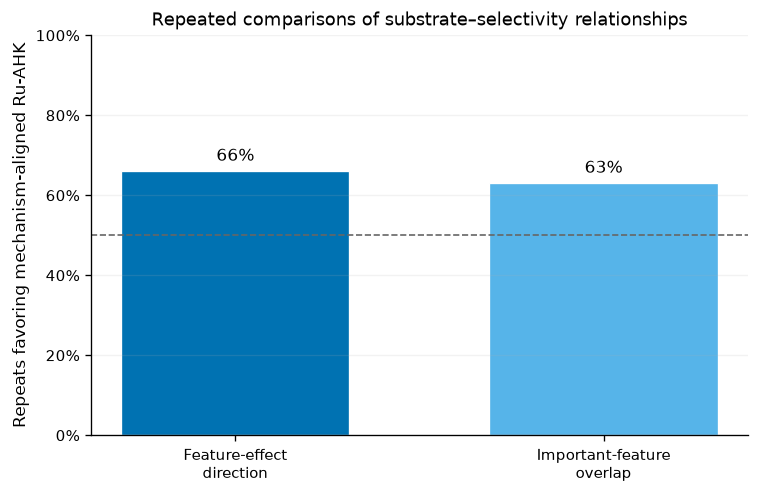

In [5]:
def safe_cosine(left, right):
    denominator = np.linalg.norm(left) * np.linalg.norm(right)
    if denominator <= 0:
        return np.nan
    return float(np.dot(left, right) / denominator)


def weighted_absolute_overlap(left, right):
    left = np.abs(np.asarray(left, dtype=float))
    right = np.abs(np.asarray(right, dtype=float))
    denominator = np.maximum(left, right).sum()
    if denominator <= 0:
        return np.nan
    return float(np.minimum(left, right).sum() / denominator)


def repeat_alignment(weights, model_specification):
    substrate = weights.loc[
        weights["model_specification"].eq(model_specification)
        & weights["block"].eq("substrate")
    ].copy()

    feature_order = [
        f"substrate_MACCS_{bit:03d}"
        for bit in RETAINED_BITS["substrate"]
    ]

    rows = []
    for repeat, group in substrate.groupby("repeat"):
        pivot = group.pivot(
            index="feature_name",
            columns="domain",
            values="coefficient",
        ).reindex(feature_order).fillna(0.0)

        vectors = {}
        for domain in DOMAIN_ORDER:
            vector = pivot[domain].to_numpy(dtype=float)
            vectors[domain] = np.where(
                np.abs(vector) >= COEFFICIENT_THRESHOLD,
                vector,
                0.0,
            )

        aligned_signed = safe_cosine(
            vectors["target"], vectors["inner"]
        )
        mismatched_signed = safe_cosine(
            vectors["target"], vectors["outer"]
        )
        aligned_overlap = weighted_absolute_overlap(
            vectors["target"], vectors["inner"]
        )
        mismatched_overlap = weighted_absolute_overlap(
            vectors["target"], vectors["outer"]
        )

        rows.append(
            {
                "model_specification": model_specification,
                "repeat": int(repeat),
                "signed_cosine_aligned": aligned_signed,
                "signed_cosine_mismatched": mismatched_signed,
                "signed_cosine_advantage": (
                    aligned_signed - mismatched_signed
                    if np.isfinite(aligned_signed)
                    and np.isfinite(mismatched_signed)
                    else np.nan
                ),
                "weighted_overlap_aligned": aligned_overlap,
                "weighted_overlap_mismatched": mismatched_overlap,
                "weighted_overlap_advantage": (
                    aligned_overlap - mismatched_overlap
                    if np.isfinite(aligned_overlap)
                    and np.isfinite(mismatched_overlap)
                    else np.nan
                ),
            }
        )

    return pd.DataFrame(rows)


ALIGNMENT_BY_REPEAT = pd.concat(
    [
        repeat_alignment(REPEAT_WEIGHTS, model_specification)
        for model_specification in MODEL_SPECIFICATIONS
    ],
    ignore_index=True,
)
ALIGNMENT_BY_REPEAT.to_csv(
    TABLE_DIR / "substrate_alignment_by_repeat.csv",
    index=False,
)


def summarize_advantage(values):
    values = pd.Series(values).dropna().astype(float)
    return {
        "median": float(values.median()),
        "interval_05": float(values.quantile(0.05)),
        "interval_95": float(values.quantile(0.95)),
        "positive_fraction": float((values > 0).mean()),
        "valid_repeats": len(values),
    }


summary_rows = []
for model_specification in MODEL_SPECIFICATIONS:
    subset = ALIGNMENT_BY_REPEAT.loc[
        ALIGNMENT_BY_REPEAT["model_specification"].eq(
            model_specification
        )
    ]
    for metric_id, column in [
        ("signed_cosine", "signed_cosine_advantage"),
        ("weighted_absolute_overlap", "weighted_overlap_advantage"),
    ]:
        summary_rows.append(
            {
                "model_specification": model_specification,
                "metric": metric_id,
                **summarize_advantage(subset[column]),
            }
        )

ALIGNMENT_SUMMARY = pd.DataFrame(summary_rows)
ALIGNMENT_SUMMARY.to_csv(
    TABLE_DIR / "substrate_alignment_summary.csv",
    index=False,
)
display(ALIGNMENT_SUMMARY.round(4))

primary = ALIGNMENT_BY_REPEAT.loc[
    ALIGNMENT_BY_REPEAT["model_specification"].eq(
        "substrate_ligand"
    )
]

metric_plot_spec = [
    {
        "column": "signed_cosine_advantage",
        "label": "Feature-effect\ndirection",
    },
    {
        "column": "weighted_overlap_advantage",
        "label": "Important-feature\noverlap",
    },
]

panel_c_rows = []
for item in metric_plot_spec:
    summary = summarize_advantage(primary[item["column"]])
    panel_c_rows.append(
        {
            "comparison": item["label"].replace("\n", " "),
            "repeats_favoring_aligned": int(
                round(summary["positive_fraction"] * summary["valid_repeats"])
            ),
            "valid_repeats": int(summary["valid_repeats"]),
            "fraction_favoring_aligned": summary["positive_fraction"],
        }
    )

PANEL_C_SUMMARY = pd.DataFrame(panel_c_rows)
PANEL_C_SUMMARY.to_csv(
    TABLE_DIR / "figure_4C_repeat_support_summary.csv",
    index=False,
)
display(PANEL_C_SUMMARY)


def save_svg(fig, path):
    fig.savefig(
        path,
        format="svg",
        bbox_inches="tight",
        facecolor="white",
    )
    ET.parse(path)


values = PANEL_C_SUMMARY["fraction_favoring_aligned"].to_numpy()
fig, ax = plt.subplots(figsize=(6.4, 4.2))
bars = ax.bar(
    np.arange(len(values)),
    values,
    width=0.62,
    color=["#0072B2", "#56B4E9"],
    edgecolor="white",
    linewidth=0.8,
)
ax.axhline(
    0.5,
    color="#666666",
    linestyle="--",
    linewidth=1.0,
)
ax.bar_label(
    bars,
    labels=[f"{value:.0%}" for value in values],
    padding=4,
    fontsize=10,
)
ax.set_xticks(np.arange(len(values)))
ax.set_xticklabels([item["label"] for item in metric_plot_spec])
ax.set_ylim(0.0, 1.0)
ax.set_yticks(np.linspace(0.0, 1.0, 6))
ax.set_yticklabels([f"{value:.0%}" for value in np.linspace(0.0, 1.0, 6)])
ax.set_ylabel("Repeats favoring mechanism-aligned Ru-AHK")
ax.set_title("Repeated comparisons of substrate–selectivity relationships")
ax.grid(axis="y", alpha=0.16)

fig.tight_layout()
PANEL_C_PATH = FIG_DIR / "figure_4C_repeat_support.svg"
save_svg(fig, PANEL_C_PATH)
plt.show()


## 5. Representative substrate feature: MACCS 132

MACCS 132 is used as a representative feature because it gives the strongest
shared stable signal in Ru-AHO and mechanism-aligned Ru-AHK under the primary
joint substrate-plus-ligand model. The main plot reports, for this feature only:

- selection frequency across balanced repeats;
- median standardized coefficient among repeats in which it is selected.

The two quantities are shown separately as bars for Ru-AHO,
mechanism-aligned Ru-AHK, and mechanism-mismatched Ru-AHK. This keeps feature
stability and effect direction visible without the multi-feature bubble matrix.


,domain_label,selection_frequency,median_selected_coefficient,selected_repeat_count,active_repeat_count
0,Ru-AHO,0.92,0.2487,92,100
1,Mechanism-aligned Ru-AHK,0.84,0.3015,84,100
2,Mechanism-mismatched Ru-AHK,0.17,0.1555,17,100


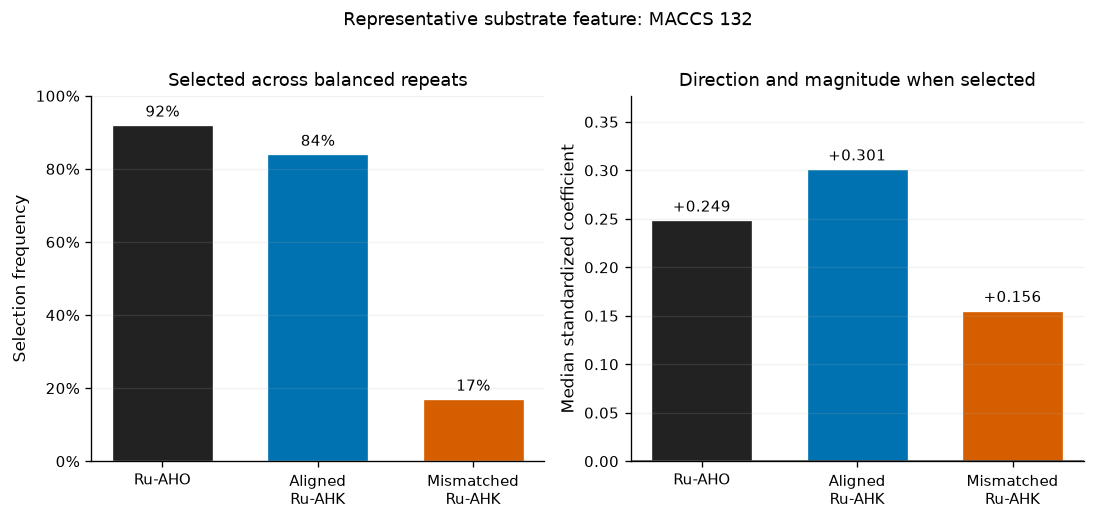

In [6]:
def aggregate_stability(weights, repeats):
    rows = []

    for keys, group in weights.groupby(
        [
            "model_specification",
            "domain",
            "block",
            "feature_name",
        ],
        sort=False,
    ):
        model_specification, domain, block, feature_name = keys
        active = group["active_in_repeat"].astype(bool)
        selected = (
            active
            & group["coefficient"].abs().ge(
                COEFFICIENT_THRESHOLD
            )
        )

        selected_weights = group.loc[
            selected,
            "coefficient",
        ]
        active_count = int(active.sum())
        selected_count = int(selected.sum())
        frequency = (
            selected_count / active_count
            if active_count
            else 0.0
        )

        if selected_count:
            positive_fraction = float(
                (selected_weights > 0).mean()
            )
            negative_fraction = float(
                (selected_weights < 0).mean()
            )
            median_selected = float(
                selected_weights.median()
            )
        else:
            positive_fraction = 0.0
            negative_fraction = 0.0
            median_selected = 0.0

        sign_stability = max(
            positive_fraction,
            negative_fraction,
        )
        stable = bool(
            frequency >= STABILITY_FREQUENCY_THRESHOLD
            and sign_stability >= SIGN_STABILITY_THRESHOLD
            and active_count >= ACTIVE_REPEAT_MINIMUM
            and abs(median_selected)
            >= COEFFICIENT_THRESHOLD
        )

        bit_value = group["bit_index"].dropna()
        bit_index = (
            int(bit_value.iloc[0])
            if len(bit_value)
            else np.nan
        )

        rows.append(
            {
                "model_specification": model_specification,
                "domain": domain,
                "block": block,
                "feature_name": feature_name,
                "bit_index": bit_index,
                "active_repeat_count": active_count,
                "selected_repeat_count": selected_count,
                "selection_frequency": frequency,
                "median_coefficient": float(
                    group["coefficient"].median()
                ),
                "median_selected_coefficient": median_selected,
                "median_absolute_selected_coefficient": abs(
                    median_selected
                ),
                "positive_fraction_selected": positive_fraction,
                "negative_fraction_selected": negative_fraction,
                "sign_stability": sign_stability,
                "stable_feature": stable,
            }
        )

    return pd.DataFrame(rows)


STABILITY = aggregate_stability(
    REPEAT_WEIGHTS,
    PRIMARY_REPEATS,
)
STABILITY.to_csv(
    TABLE_DIR / "feature_stability_summary.csv",
    index=False,
)

PRIMARY_SUBSTRATE_STABILITY = STABILITY.loc[
    STABILITY["model_specification"].eq(
        "substrate_ligand"
    )
    & STABILITY["block"].eq("substrate")
].copy()

wide = PRIMARY_SUBSTRATE_STABILITY.pivot(
    index=["feature_name", "bit_index"],
    columns="domain",
    values=[
        "selection_frequency",
        "median_selected_coefficient",
        "stable_feature",
    ],
)
wide.columns = [
    f"{metric}__{domain}"
    for metric, domain in wide.columns
]
wide = wide.reset_index()

REPRESENTATIVE_BIT = 132
REPRESENTATIVE_NAME = f"substrate_MACCS_{REPRESENTATIVE_BIT:03d}"

if REPRESENTATIVE_NAME not in set(
    PRIMARY_SUBSTRATE_STABILITY["feature_name"]
):
    raise RuntimeError(
        "MACCS 132 is absent from the retained substrate feature universe."
    )

MACCS_132_SUMMARY = PRIMARY_SUBSTRATE_STABILITY.loc[
    PRIMARY_SUBSTRATE_STABILITY["feature_name"].eq(
        REPRESENTATIVE_NAME
    )
].copy()
MACCS_132_SUMMARY["domain_order"] = MACCS_132_SUMMARY["domain"].map(
    {domain: index for index, domain in enumerate(DOMAIN_ORDER)}
)
MACCS_132_SUMMARY["domain_label"] = MACCS_132_SUMMARY["domain"].map(
    DOMAIN_LABELS
)
MACCS_132_SUMMARY = MACCS_132_SUMMARY.sort_values(
    "domain_order"
).reset_index(drop=True)
MACCS_132_SUMMARY.to_csv(
    TABLE_DIR / "figure_4D_MACCS_132_summary.csv",
    index=False,
)
display(
    MACCS_132_SUMMARY[
        [
            "domain_label",
            "selection_frequency",
            "median_selected_coefficient",
            "selected_repeat_count",
            "active_repeat_count",
        ]
    ].round(4)
)

plot_labels = [
    "Ru-AHO",
    "Aligned\nRu-AHK",
    "Mismatched\nRu-AHK",
]
plot_colors = [DOMAIN_COLORS[domain] for domain in DOMAIN_ORDER]
x_positions = np.arange(len(DOMAIN_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2))

frequency_values = MACCS_132_SUMMARY[
    "selection_frequency"
].to_numpy(dtype=float)
frequency_bars = axes[0].bar(
    x_positions,
    frequency_values,
    color=plot_colors,
    width=0.65,
    edgecolor="white",
    linewidth=0.8,
)
axes[0].bar_label(
    frequency_bars,
    labels=[f"{value:.0%}" for value in frequency_values],
    padding=3,
)
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(plot_labels)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_yticks(np.linspace(0.0, 1.0, 6))
axes[0].set_yticklabels(
    [f"{value:.0%}" for value in np.linspace(0.0, 1.0, 6)]
)
axes[0].set_ylabel("Selection frequency")
axes[0].set_title("Selected across balanced repeats")
axes[0].grid(axis="y", alpha=0.16)

coefficient_values = MACCS_132_SUMMARY[
    "median_selected_coefficient"
].to_numpy(dtype=float)
coefficient_bars = axes[1].bar(
    x_positions,
    coefficient_values,
    color=plot_colors,
    width=0.65,
    edgecolor="white",
    linewidth=0.8,
)
axes[1].bar_label(
    coefficient_bars,
    labels=[f"{value:+.3f}" for value in coefficient_values],
    padding=3,
)
axes[1].axhline(0.0, color="#555555", linewidth=0.9)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(plot_labels)
coefficient_span = max(np.abs(coefficient_values).max(), 0.10)
axes[1].set_ylim(
    min(0.0, coefficient_values.min() - 0.18 * coefficient_span),
    max(0.0, coefficient_values.max() + 0.25 * coefficient_span),
)
axes[1].set_ylabel("Median standardized coefficient")
axes[1].set_title("Direction and magnitude when selected")
axes[1].grid(axis="y", alpha=0.16)

fig.suptitle("Representative substrate feature: MACCS 132", y=1.02)
fig.tight_layout()
PANEL_D_PATH = FIG_DIR / "figure_4D_MACCS_132_statistics.svg"
save_svg(fig, PANEL_D_PATH)
plt.show()


## 6. Representative structures containing MACCS 132

The structure sheet is restricted to MACCS 132. For each domain, three unique
substrates containing the feature are selected by a MACCS medoid followed by
farthest-point diversity sampling. The outcome label is not used to select the
displayed structures. Matching atoms are highlighted when the MACCS SMARTS
definition permits an explicit substructure match.


Representative substrate feature: substrate_MACCS_132


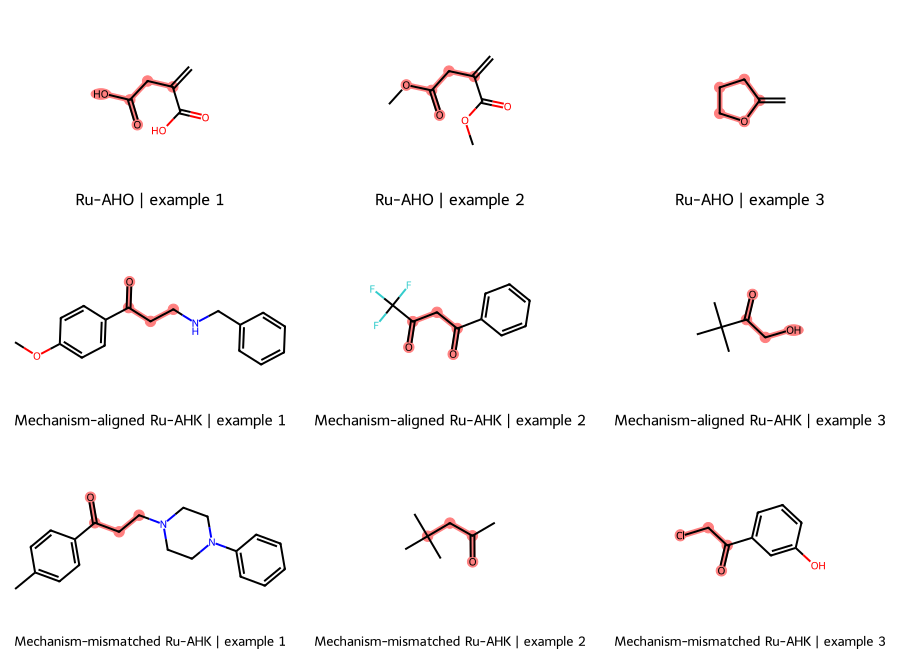

,feature_name,bit_index,domain,row_id,canonical_substrate,selection_rule,uses_ddG_for_selection
0,substrate_MACCS_132,132,target,target_0089,C=C(CC(=O)O)C(=O)O,MACCS medoid followed by farthest-point diversity,False
1,substrate_MACCS_132,132,target,target_0015,C=C(CC(=O)OC)C(=O)OC,MACCS medoid followed by farthest-point diversity,False
2,substrate_MACCS_132,132,target,target_0049,C=C1CCCO1,MACCS medoid followed by farthest-point diversity,False
3,substrate_MACCS_132,132,inner,inner_0067,COc1ccc(C(=O)CCNCc2ccccc2)cc1,MACCS medoid followed by farthest-point diversity,False
4,substrate_MACCS_132,132,inner,inner_0437,O=C(CC(=O)C(F)(F)F)c1ccccc1,MACCS medoid followed by farthest-point diversity,False
5,substrate_MACCS_132,132,inner,inner_0223,CC(C)(C)C(=O)CO,MACCS medoid followed by farthest-point diversity,False
6,substrate_MACCS_132,132,outer,outer_0110,Cc1ccc(C(=O)CCN2CCN(c3ccccc3)CC2)cc1,MACCS medoid followed by farthest-point diversity,False
7,substrate_MACCS_132,132,outer,outer_1248,CC(=O)CC(C)(C)C,MACCS medoid followed by farthest-point diversity,False
8,substrate_MACCS_132,132,outer,outer_0274,O=C(CCl)c1cccc(O)c1,MACCS medoid followed by farthest-point diversity,False


In [7]:
REPRESENTATIVE_BIT = 132
REPRESENTATIVE_NAME = f"substrate_MACCS_{REPRESENTATIVE_BIT:03d}"

if REPRESENTATIVE_NAME not in set(
    PRIMARY_SUBSTRATE_STABILITY["feature_name"]
):
    raise RuntimeError(
        "MACCS 132 is absent from the retained substrate feature universe."
    )

print("Representative substrate feature:", REPRESENTATIVE_NAME)


def fingerprint(smiles):
    return MACCSkeys.GenMACCSKeys(
        Chem.MolFromSmiles(smiles)
    )


def tanimoto_distance(left, right):
    return 1.0 - DataStructs.TanimotoSimilarity(left, right)


def select_medoid_and_diverse(smiles_values, n_select=3):
    unique_smiles = sorted(set(smiles_values))
    if len(unique_smiles) <= n_select:
        return unique_smiles

    fingerprints = [fingerprint(smiles) for smiles in unique_smiles]
    similarity_sums = []
    for index, fp in enumerate(fingerprints):
        similarities = DataStructs.BulkTanimotoSimilarity(
            fp,
            fingerprints,
        )
        similarity_sums.append(float(np.mean(similarities)))

    selected = [int(np.argmax(similarity_sums))]

    while len(selected) < n_select:
        best_index = None
        best_distance = -np.inf

        for candidate in range(len(unique_smiles)):
            if candidate in selected:
                continue
            minimum_distance = min(
                tanimoto_distance(
                    fingerprints[candidate],
                    fingerprints[chosen],
                )
                for chosen in selected
            )
            if (
                minimum_distance > best_distance
                or (
                    np.isclose(minimum_distance, best_distance)
                    and (
                        best_index is None
                        or unique_smiles[candidate]
                        < unique_smiles[best_index]
                    )
                )
            ):
                best_index = candidate
                best_distance = minimum_distance

        selected.append(int(best_index))

    return [unique_smiles[index] for index in selected]


def bit_highlight_atoms(molecule, bit):
    smarts, count = MACCSkeys.smartsPatts[int(bit)]
    if smarts == "?" or count > 0 or bit in {125, 166}:
        return []
    pattern = Chem.MolFromSmarts(smarts)
    if pattern is None:
        return []
    atoms = set()
    for match in molecule.GetSubstructMatches(
        pattern,
        uniquify=True,
    ):
        atoms.update(match)
    return sorted(atoms)


structure_rows = []
molecules = []
legends = []
highlight_atoms = []

for domain in DOMAIN_ORDER:
    active_mask = MATRICES[(domain, "substrate")][
        :,
        REPRESENTATIVE_BIT,
    ].astype(bool)
    active_table = DOMAINS[domain].loc[
        active_mask
    ].copy()

    selected_smiles = select_medoid_and_diverse(
        active_table["canonical_substrate"],
        n_select=3,
    )

    for rank, smiles in enumerate(selected_smiles, start=1):
        molecule = Chem.MolFromSmiles(smiles)
        row = active_table.loc[
            active_table["canonical_substrate"].eq(smiles)
        ].sort_values("row_id").iloc[0]

        molecules.append(molecule)
        highlight_atoms.append(
            bit_highlight_atoms(
                molecule,
                REPRESENTATIVE_BIT,
            )
        )
        legends.append(
            f"{DOMAIN_LABELS[domain]} | example {rank}"
        )
        structure_rows.append(
            {
                "feature_name": REPRESENTATIVE_NAME,
                "bit_index": REPRESENTATIVE_BIT,
                "domain": domain,
                "row_id": row["row_id"],
                "canonical_substrate": smiles,
                "selection_rule": (
                    "MACCS medoid followed by farthest-point diversity"
                ),
                "uses_ddG_for_selection": False,
            }
        )

STRUCTURE_MANIFEST = pd.DataFrame(structure_rows)
STRUCTURE_MANIFEST.to_csv(
    TABLE_DIR / "representative_substrate_structure_manifest.csv",
    index=False,
)

svg = Draw.MolsToGridImage(
    molecules,
    molsPerRow=3,
    subImgSize=(300, 220),
    legends=legends,
    highlightAtomLists=highlight_atoms,
    useSVG=True,
)

svg_text = svg.data if hasattr(svg, "data") else str(svg)
opening_end = svg_text.find(">")
svg_text = (
    svg_text[: opening_end + 1]
    + '<rect x="0" y="0" width="100%" height="100%" fill="#ffffff"/>'
    + svg_text[opening_end + 1 :]
)

MACCS_132_STRUCTURE_PATH = (
    STRUCTURE_DIR / "MACCS_132_representative_activations.svg"
)
MACCS_132_STRUCTURE_PATH.write_text(svg_text, encoding="utf-8")
ET.parse(MACCS_132_STRUCTURE_PATH)
display(SVG(filename=str(MACCS_132_STRUCTURE_PATH)))
display(STRUCTURE_MANIFEST)

## 7. Model-specification sensitivity and evidence boundary

The primary interpretation uses the joint substrate-plus-ligand model. The
substrate-only and condition-adjusted models are reported as specification
sensitivities, using the same balanced-repeat logic and the same substrate
alignment metrics.

In [8]:
SENSITIVITY_TABLE = ALIGNMENT_SUMMARY.pivot(
    index="model_specification",
    columns="metric",
    values=[
        "median",
        "interval_05",
        "interval_95",
        "positive_fraction",
        "valid_repeats",
    ],
)
SENSITIVITY_TABLE.columns = [
    f"{statistic}__{metric}"
    for statistic, metric in SENSITIVITY_TABLE.columns
]
SENSITIVITY_TABLE = SENSITIVITY_TABLE.reset_index()
SENSITIVITY_TABLE.to_csv(
    TABLE_DIR / "model_specification_sensitivity.csv",
    index=False,
)
display(SENSITIVITY_TABLE.round(4))

primary_summary = ALIGNMENT_SUMMARY.loc[
    ALIGNMENT_SUMMARY["model_specification"].eq(
        "substrate_ligand"
    )
].set_index("metric")

both_positive = bool((primary_summary["median"] > 0).all())
both_strict = bool((primary_summary["interval_05"] > 0).all())

if both_strict:
    EVIDENCE_LEVEL = "strong_support"
elif both_positive:
    EVIDENCE_LEVEL = "partial_support"
else:
    EVIDENCE_LEVEL = "mixed_or_unsupported"

EVIDENCE_SUMMARY = pd.DataFrame(
    [
        {
            "evidence_level": EVIDENCE_LEVEL,
            "primary_model": "substrate + ligand",
            "interpreted_block": "substrate coefficients only",
            "signed_cosine_median_advantage": primary_summary.loc[
                "signed_cosine",
                "median",
            ],
            "weighted_overlap_median_advantage": primary_summary.loc[
                "weighted_absolute_overlap",
                "median",
            ],
            "statement": (
                "The result is descriptive evidence for partial "
                "substrate-feature compatibility only; it is not a "
                "causal or stereodetermining proof."
            ),
        }
    ]
)
EVIDENCE_SUMMARY.to_csv(
    TABLE_DIR / "evidence_summary.csv",
    index=False,
)
display(EVIDENCE_SUMMARY)

,model_specification,median__signed_cosine,median__weighted_absolute_overlap,interval_05__signed_cosine,interval_05__weighted_absolute_overlap,interval_95__signed_cosine,interval_95__weighted_absolute_overlap,positive_fraction__signed_cosine,positive_fraction__weighted_absolute_overlap,valid_repeats__signed_cosine,valid_repeats__weighted_absolute_overlap
0,substrate_ligand,0.0813,0.0331,-0.2177,-0.0958,0.4801,0.2214,0.66,0.63,100.0,100.0
1,substrate_ligand_conditions,0.1367,0.0083,-0.2446,-0.1169,0.5835,0.2144,0.65,0.56,100.0,100.0
2,substrate_only,0.1562,0.0364,-0.0830,-0.0981,0.4740,0.1525,0.84,0.65,100.0,100.0


,evidence_level,primary_model,interpreted_block,signed_cosine_median_advantage,weighted_overlap_median_advantage,statement
0,partial_support,substrate + ligand,substrate coefficients only,0.081326,0.03314,The result is descriptive evidence for partial...


## 8. Output validation

The final checks confirm that the two-bar repeat-support plot, the MACCS 132
domain-statistics plot, and the MACCS 132 representative structure sheet exist
and are valid SVG files. They also confirm that the primary model includes both
substrate and ligand blocks while all cross-domain alignment metrics use only
the substrate block.


In [9]:
expected_figures = [
    PANEL_C_PATH,
    PANEL_D_PATH,
    MACCS_132_STRUCTURE_PATH,
]

for path in expected_figures:
    if not path.exists():
        raise FileNotFoundError(path)
    ET.parse(path)

primary_weights = REPEAT_WEIGHTS.loc[
    REPEAT_WEIGHTS["model_specification"].eq(
        "substrate_ligand"
    )
]
if set(primary_weights["block"]) != {"substrate", "ligand"}:
    raise ValueError(
        "The primary model must contain substrate and ligand blocks."
    )

expected_primary_rows = (
    PRIMARY_REPEATS
    * len(DOMAIN_ORDER)
    * (FEATURE_CAP + FEATURE_CAP)
)
if len(primary_weights) != expected_primary_rows:
    raise ValueError(
        f"Unexpected primary weight count: {len(primary_weights)}; "
        f"expected {expected_primary_rows}."
    )

if ALIGNMENT_BY_REPEAT.replace(
    [np.inf, -np.inf],
    np.nan,
).drop(
    columns=[
        "signed_cosine_aligned",
        "signed_cosine_mismatched",
        "signed_cosine_advantage",
        "weighted_overlap_aligned",
        "weighted_overlap_mismatched",
        "weighted_overlap_advantage",
    ]
).isna().any().any():
    raise ValueError("Unexpected missing identifiers in alignment table.")

print("All 2.2 outputs passed validation.")
print(
    "Primary model: substrate and ligand fitted jointly; "
    "cross-domain interpretation restricted to substrate coefficients."
)

All 2.2 outputs passed validation.
Primary model: substrate and ligand fitted jointly; cross-domain interpretation restricted to substrate coefficients.
